## **Data Cleaning, Wrangling, and Principal Component Analysis (PCA)**



In [ ]:
# Loading neccesary libraries:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import  stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')
plt.style.use('default')

In [ ]:
%matplotlib inline
# without this the plots would be opened  in a new window (not browser)
# with this instruction plots will be included in the notebook

In [ ]:
# Use %config InlineBackend.figure_format = 'retina'
# after %matplotlib inline to render higher resolution images
%config InlineBackend.figure_format = 'retina'

In [ ]:
# If you wish to use Google colab, the following code will allow you to mount your Google Drive. Otherwise, comment on the following lines.
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
# To print multiple outputs
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
# Set it to None to display all columns in the dataframe
pd.set_option('display.max_columns', None)

**Data Loading:**

In [ ]:
#Reading the data from google drive
data=pd.read_csv('gdrive/MyDrive/WS5/ws5data/cereals.csv')

print("Data imported successfully")

# Display first 5 rows
data.head()

Data imported successfully


,Name,Manuf,Type,Calories,Protein,Fat,Sodium,Fiber,Carbo,Sugars,Potass,Vitamins,Shelf,Weight,Cups,Rating
0,100%_Bran,N,C,70,4,1,130,10.0,5.0,6.0,280.0,25,3,1.0,0.33,68.402973
1,100%_Natural_Bran,Q,C,120,3,5,15,2.0,8.0,8.0,135.0,0,3,1.0,1.00,33.983679
2,All-Bran,K,C,70,4,1,260,9.0,7.0,5.0,320.0,25,3,1.0,0.33,59.425505
3,All-Bran_with_Extra_Fiber,K,C,50,4,0,140,14.0,8.0,0.0,330.0,25,3,1.0,0.50,93.704912
4,Almond_Delight,R,C,110,2,2,200,1.0,14.0,8.0,NaN,25,3,1.0,0.75,34.384843


**Data Cleaning and Wrangling:** handle missing data, outliers, and other inconsistencies in the dataset.


In [ ]:
# Handle missing values (drop or impute)

# drop rows with missing value
#data=data.dropna()

# drop columns with missing values
#data = data.dropna(axis=1)

# Replace -1 in 'Potass' (Potassium) with NaN (if there was -1)
#data['Potass'] = data['Potass'].replace(-1, pd.NA)

# impute missing values using median for 'Potass'
#data['Potass'] = data['Potass'].fillna(data['Potass'].median())

# Checking for missing values
print("Checking for missing values\n")
print(data.isnull().sum())

# fill missing values with column median. if categorical, fill with mode.
# Fill numeric columns with median
numeric_columns = data.select_dtypes(include=['number']).columns
data[numeric_columns] = data[numeric_columns].fillna(data[numeric_columns].median())

# Fill categorical columns with mode
categorical_columns = data.select_dtypes(include=['object']).columns
for column in categorical_columns:
    data[column] = data[column].fillna(data[column].mode())

# Verify that missing values have been handled
print("\nVerify that missing values have been handled\n")
print(data.isnull().sum())






# Calculate the z-scores
numeric_columns = data.select_dtypes(include=['number']).columns
z_scores = stats.zscore(data[numeric_columns])

#table assigning true/false to each row
#outliers = (np.abs(z_scores) > 3).any(axis=1)

# with 3 standard deviations
#table assigning true/false to each value
outliers = (np.abs(z_scores) > 3)

print("\nOutliers:\n")
print(outliers)

# Remove rows with outliers
#data = data[~outliers]

# Replace outliers with NaN
data[numeric_columns] = data[numeric_columns].mask(outliers)

# Checking for missing values
print("\nChecking for missing values after replacing outliers with NaN\n")
print(data.isnull().sum())

# fill missing values with column median. if categorical, fill with mode.
# Fill numeric columns with median
numeric_columns = data.select_dtypes(include=['number']).columns
data[numeric_columns] = data[numeric_columns].fillna(data[numeric_columns].median())

# Fill categorical columns with mode
categorical_columns = data.select_dtypes(include=['object']).columns
for column in categorical_columns:
    data[column] = data[column].fillna(data[column].mode())

# Verify that missing values have been handled
print("\nVerify that missing values have been handled\n")
print(data.isnull().sum())








# Convert categorical columns to numerical using one-hot encoding

# one-hot encode
data = pd.get_dummies(data, columns=['Manuf', 'Type'])

# Display first 5 rows
print("\nAfter one hot encode:\n")
data.head()




# Any other data wrangling

# summary statistics
data.describe()



print("\nPrepared Data:\n")
print(data)


Checking for missing values

Name        0
Manuf       0
Type        0
Calories    0
Protein     0
Fat         0
Sodium      0
Fiber       0
Carbo       1
Sugars      1
Potass      2
Vitamins    0
Shelf       0
Weight      0
Cups        0
Rating      0
dtype: int64

Verify that missing values have been handled

Name        0
Manuf       0
Type        0
Calories    0
Protein     0
Fat         0
Sodium      0
Fiber       0
Carbo       0
Sugars      0
Potass      0
Vitamins    0
Shelf       0
Weight      0
Cups        0
Rating      0
dtype: int64

Outliers:

    Calories  Protein    Fat  Sodium  Fiber  Carbo  Sugars  Potass  Vitamins  \
0      False    False  False   False   True  False   False   False     False   
1      False    False   True   False  False  False   False   False     False   
2      False    False  False   False  False  False   False    True     False   
3      False    False  False   False   True  False   False    True     False   
4      False    False  False   False  

,Name,Calories,Protein,Fat,Sodium,Fiber,Carbo,Sugars,Potass,Vitamins,Shelf,Weight,Cups,Rating,Manuf_A,Manuf_G,Manuf_K,Manuf_N,Manuf_P,Manuf_Q,Manuf_R,Type_C,Type_H
0,100%_Bran,70,4.0,1.0,130,1.5,5.0,6.0,280.0,25.0,3,1.0,0.33,68.402973,False,False,False,True,False,False,False,True,False
1,100%_Natural_Bran,120,3.0,1.0,15,2.0,8.0,8.0,135.0,0.0,3,1.0,1.00,33.983679,False,False,False,False,False,True,False,True,False
2,All-Bran,70,4.0,1.0,260,9.0,7.0,5.0,90.0,25.0,3,1.0,0.33,59.425505,False,False,True,False,False,False,False,True,False
3,All-Bran_with_Extra_Fiber,50,4.0,0.0,140,1.5,8.0,0.0,90.0,25.0,3,1.0,0.50,40.253086,False,False,True,False,False,False,False,True,False
4,Almond_Delight,110,2.0,2.0,200,1.0,14.0,8.0,90.0,25.0,3,1.0,0.75,34.384843,False,False,False,False,False,False,True,True,False


,Calories,Protein,Fat,Sodium,Fiber,Carbo,Sugars,Potass,Vitamins,Shelf,Weight,Cups,Rating
count,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000
mean,106.883117,2.441558,0.961039,159.675325,1.879221,14.798701,7.025974,92.337662,22.402597,2.207792,1.029610,0.821039,41.971525
std,19.484119,0.938833,0.895038,83.832295,1.720108,3.881688,4.349755,58.667128,7.678164,0.832524,0.097393,0.232716,12.752975
min,50.000000,1.000000,0.000000,0.000000,0.000000,5.000000,0.000000,15.000000,0.000000,1.000000,0.830000,0.250000,18.042851
25%,100.000000,2.000000,0.000000,130.000000,1.000000,12.000000,3.000000,45.000000,25.000000,1.000000,1.000000,0.670000,33.174094
50%,110.000000,2.000000,1.000000,180.000000,1.500000,14.500000,7.000000,90.000000,25.000000,2.000000,1.000000,0.750000,40.253086
75%,110.000000,3.000000,1.000000,210.000000,3.000000,17.000000,11.000000,115.000000,25.000000,3.000000,1.000000,1.000000,50.764999
max,160.000000,5.000000,3.000000,320.000000,9.000000,23.000000,15.000000,280.000000,25.000000,3.000000,1.330000,1.500000,74.472949



Prepared Data:

                          Name  Calories  Protein  Fat  Sodium  Fiber  Carbo  \
0                   100%_Bran         70      4.0  1.0     130    1.5    5.0   
1           100%_Natural_Bran        120      3.0  1.0      15    2.0    8.0   
2                    All-Bran         70      4.0  1.0     260    9.0    7.0   
3   All-Bran_with_Extra_Fiber         50      4.0  0.0     140    1.5    8.0   
4              Almond_Delight        110      2.0  2.0     200    1.0   14.0   
..                         ...       ...      ...  ...     ...    ...    ...   
72                    Triples        110      2.0  1.0     250    0.0   21.0   
73                       Trix        110      1.0  1.0     140    0.0   13.0   
74                 Wheat_Chex        100      3.0  1.0     230    3.0   17.0   
75                   Wheaties        100      3.0  1.0     200    3.0   17.0   
76        Wheaties_Honey_Gold        110      2.0  1.0     200    1.0   16.0   

    Sugars  Potass  Vi

**Exploratory Data Analysis (EDA):** Visually inspect and understand the dataset's distribution and potential correlations.


array([[<Axes: title={'center': 'Calories'}>,
        <Axes: title={'center': 'Protein'}>,
        <Axes: title={'center': 'Fat'}>,
        <Axes: title={'center': 'Sodium'}>],
       [<Axes: title={'center': 'Fiber'}>,
        <Axes: title={'center': 'Carbo'}>,
        <Axes: title={'center': 'Sugars'}>,
        <Axes: title={'center': 'Potass'}>],
       [<Axes: title={'center': 'Vitamins'}>,
        <Axes: title={'center': 'Shelf'}>,
        <Axes: title={'center': 'Weight'}>,
        <Axes: title={'center': 'Cups'}>],
       [<Axes: title={'center': 'Rating'}>, <Axes: >, <Axes: >, <Axes: >]],
      dtype=object)

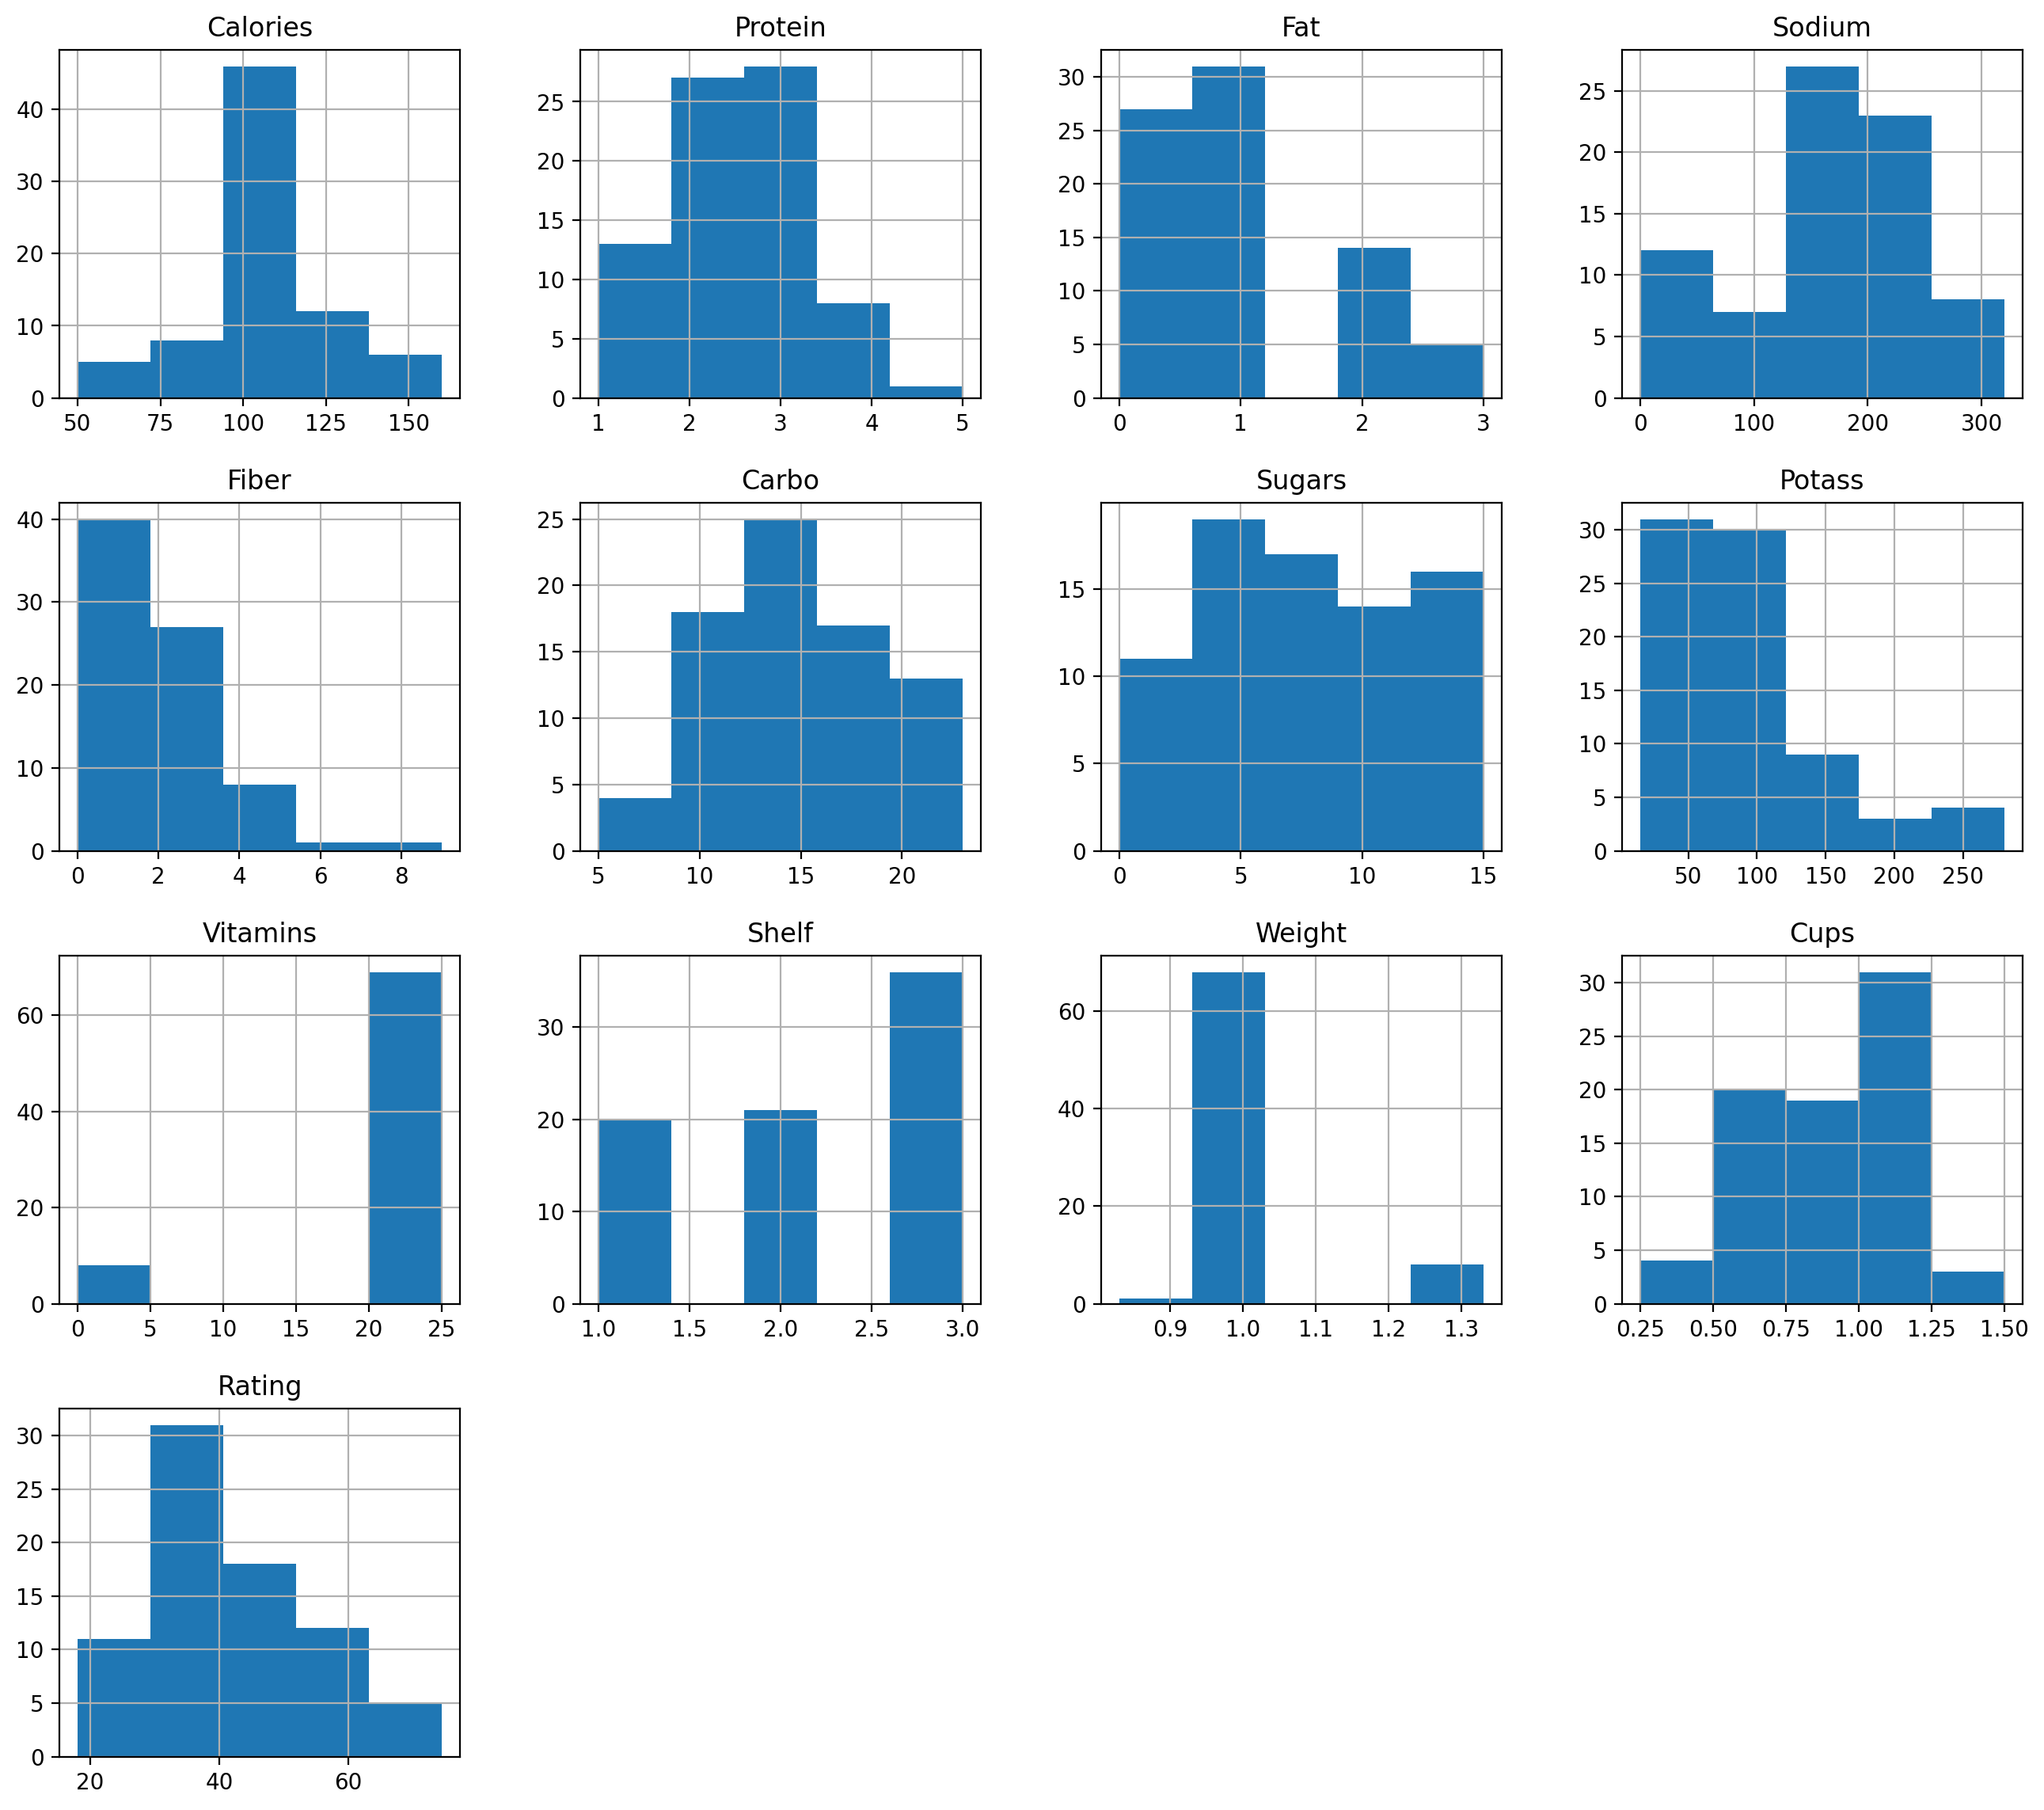

<Figure size 1000x600 with 0 Axes>

<Axes: xlabel='Rating', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of Cereal Ratings')

Text(0.5, 0, 'Rating')

Text(0, 0.5, 'Frequency')

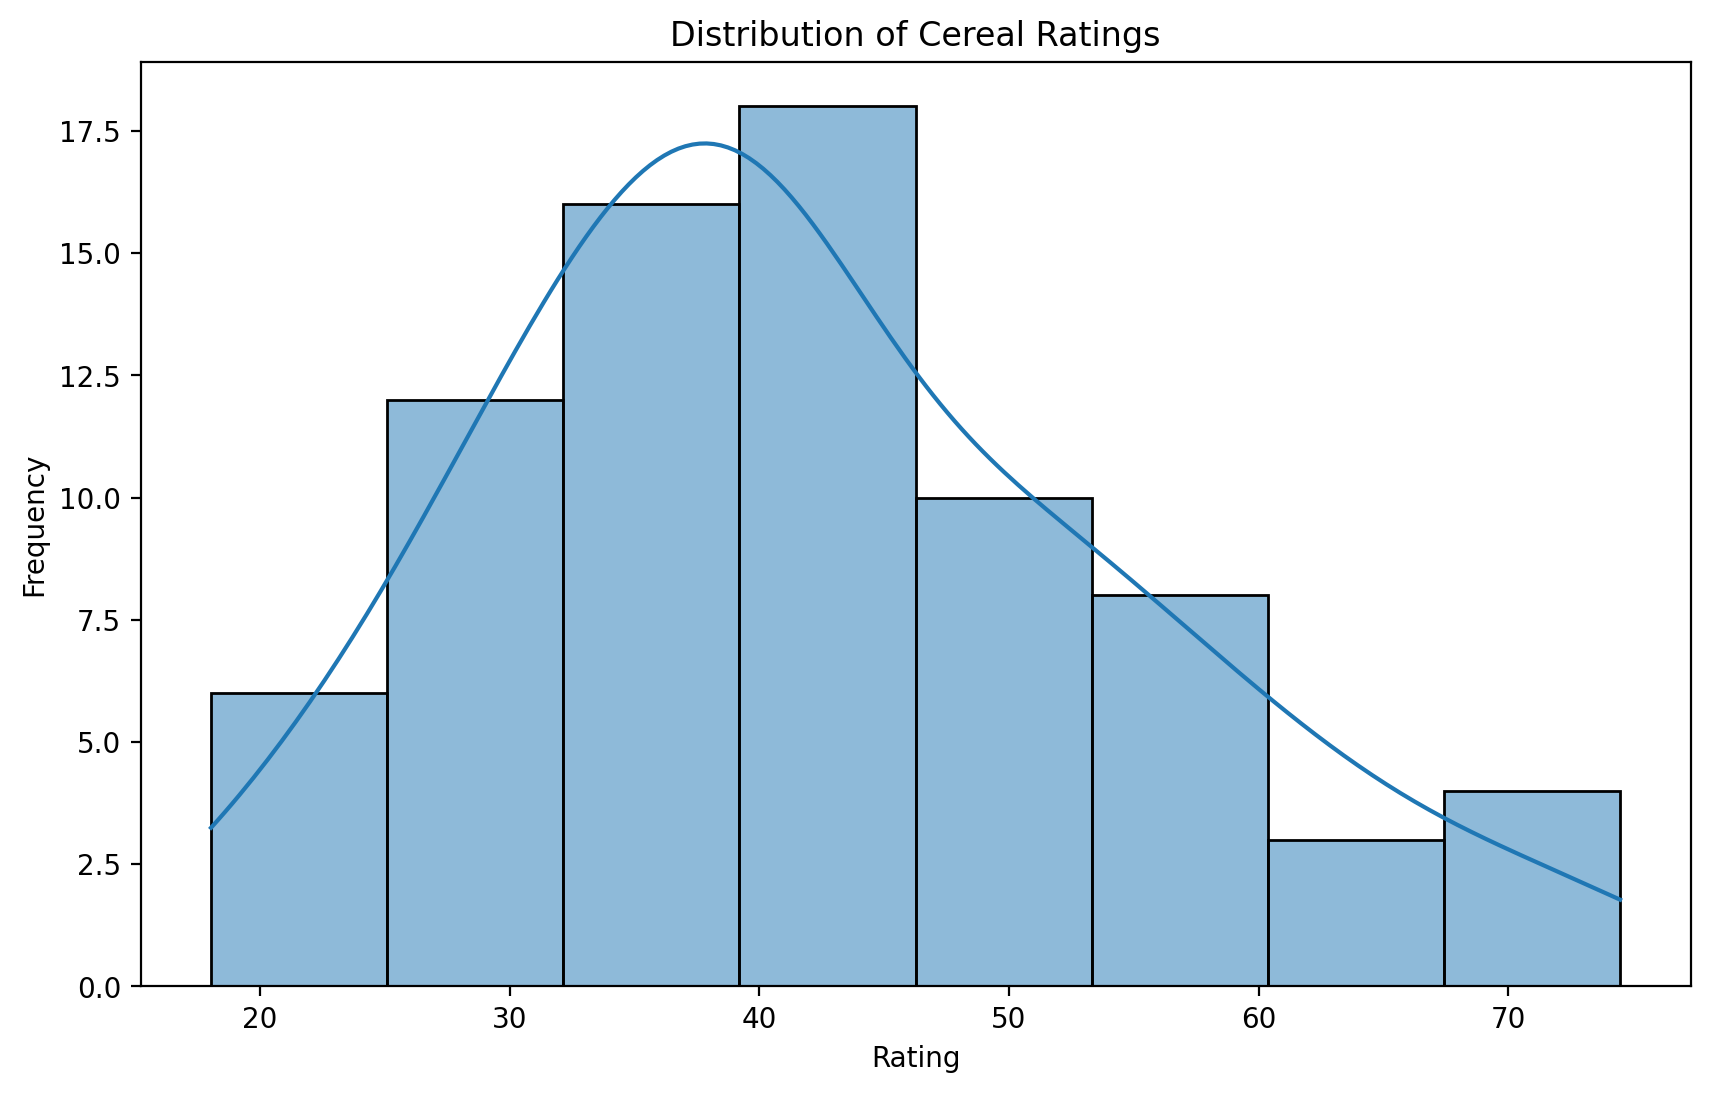

<Figure size 1200x800 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Correlation Heatmap')

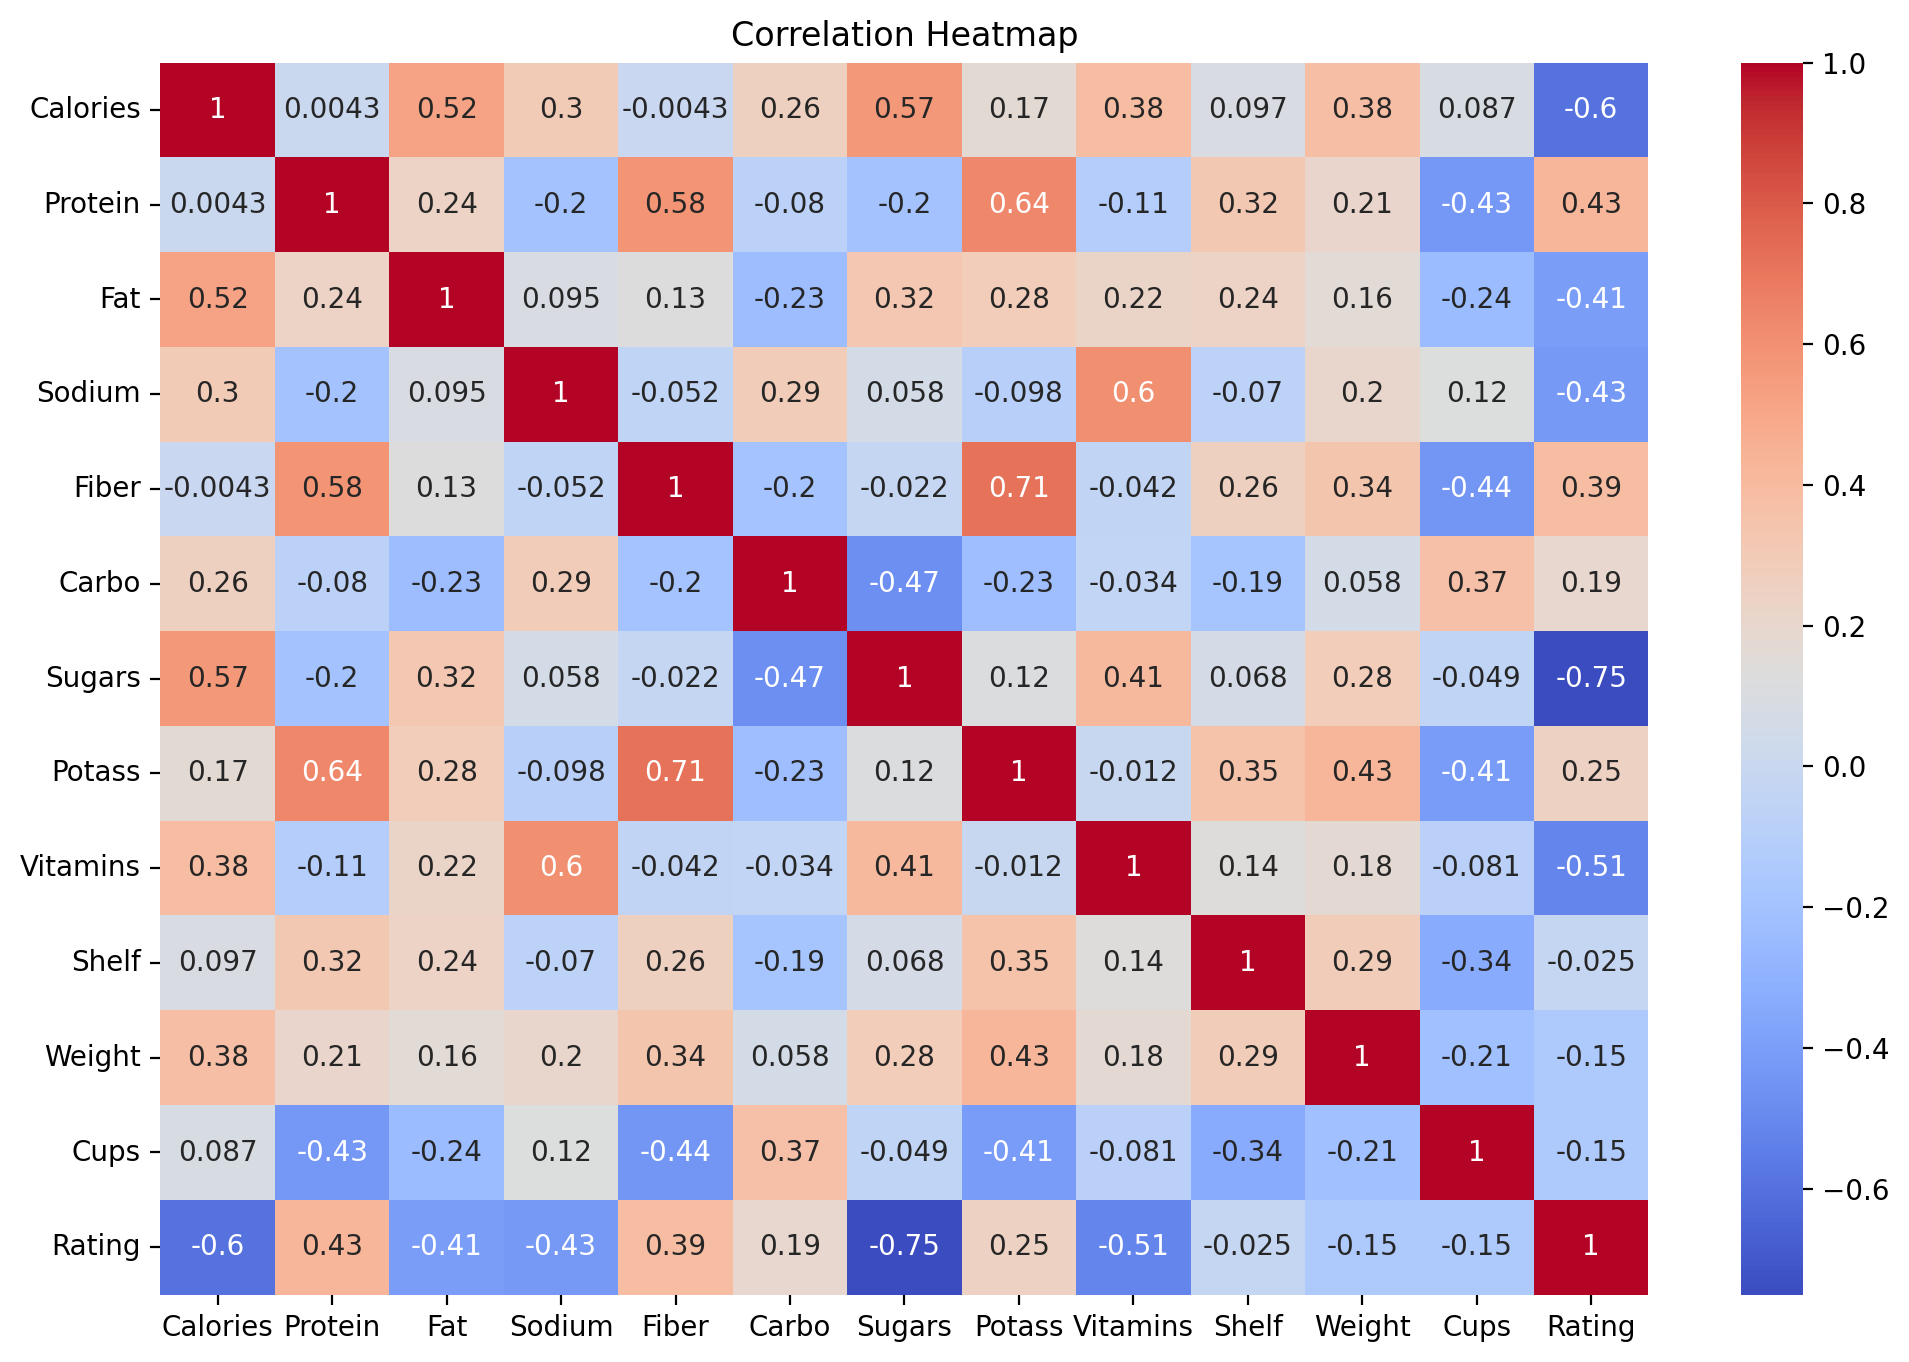

In [ ]:
# numeric columns
numeric_columns = data.select_dtypes(include=['number']).columns

# histograms
data[numeric_columns].hist(bins=5, figsize=(16, 14))

plt.savefig('gdrive/MyDrive/WS5/ws5data/group_7_ws5_graph_1.jpg')
plt.show()

# Visualize the distribution of the 'Rating' column
plt.figure(figsize=(10,6))
sns.histplot(data['Rating'], kde=True)
plt.title('Distribution of Cereal Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.savefig('gdrive/MyDrive/WS5/ws5data/group_7_ws5_graph_2.jpg')
plt.show()



# Correlation heatmap to explore relationships
plt.figure(figsize=(12,8))
sns.heatmap(data[numeric_columns].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('gdrive/MyDrive/WS5/ws5data/group_7_ws5_graph_3.jpg')
plt.show()






#sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
#plt.savefig("gdrive/MyDrive/WS5/ws5data/group_7_ws5_graph_123.jpg", bbox_inches='tight', dpi=300)

**Principal Component Analysis (PCA)**: Apply the concept of PCA for dimensionality reduction for this dataset. Remember that the main goal is to identify and quantify patterns in data, specifically the directions where the data varies the most. By reducing dimensionality, we can capture most of the variability in data with fewer variables, which can simplify models and sometimes lead to better generalization in machine learning tasks.
  -	Scale the data: before applying PCA, it is crucial to standardize (or scale) the dataset so that each feature has a mean of 0 and a standard deviation of 1. This ensures that the principal components are not biased by the absolute magnitudes of different features.
  - Apply PCA on the scaled data. Then, compute the result of transforming the original data into the number of principal components equal to the number of original features.
  - Visualize the explained variance for each component. It would help if you calculated the cumulative sum of explained variances. It helps understand how much total variance is explained by n number of components. Ideally, one would choose the number of components such that a significant proportion (e.g., 95%) of the variance is retained. By examining the scree plot, one can determine a suitable cutoff.


Scaled Data:
 [[-1.90539669  1.67086198  0.04381547 ... -0.306024   -2.12387042
   2.08616196]
 [ 0.67762347  0.59872554  0.04381547 ... -0.306024    0.77405275
  -0.6304589 ]
 [-1.90539669  1.67086198  0.04381547 ... -0.306024   -2.12387042
   1.37759493]
 ...
 [-0.35558459  0.59872554  0.04381547 ... -0.306024   -0.65328254
   0.61688918]
 [-0.35558459  0.59872554  0.04381547 ... -0.306024    0.77405275
   0.75933301]
 [ 0.16101944 -0.47341089  0.04381547 ... -0.306024   -0.30726187
  -0.45651267]]

PCA Transformed Data:
 [[ 2.27792937  3.6417393  -1.66708105 ...  2.43640226  0.81465401
   0.40257793]
 [ 0.45902125  1.29043472 -2.1688698  ... -0.08489599  0.24814938
  -0.95373962]
 [ 2.43492622  3.3902278  -0.42198265 ... -2.30969423  0.28886459
   0.23810436]
 ...
 [-0.19100255  0.84051441  1.18990029 ...  0.14103521 -0.15311162
  -0.05605789]
 [-0.70489221  0.71219694  1.27329666 ... -0.10822731 -0.13451579
  -0.08170285]
 [-0.76082781 -1.12911007  0.03951222 ...  0.1040692  -0.097

<Figure size 1000x600 with 0 Axes>

Text(0.5, 1.0, 'Cumulative Explained Variance by Principal Components')

Text(0.5, 0, 'Number of Principal Components')

Text(0, 0.5, 'Cumulative Explained Variance')

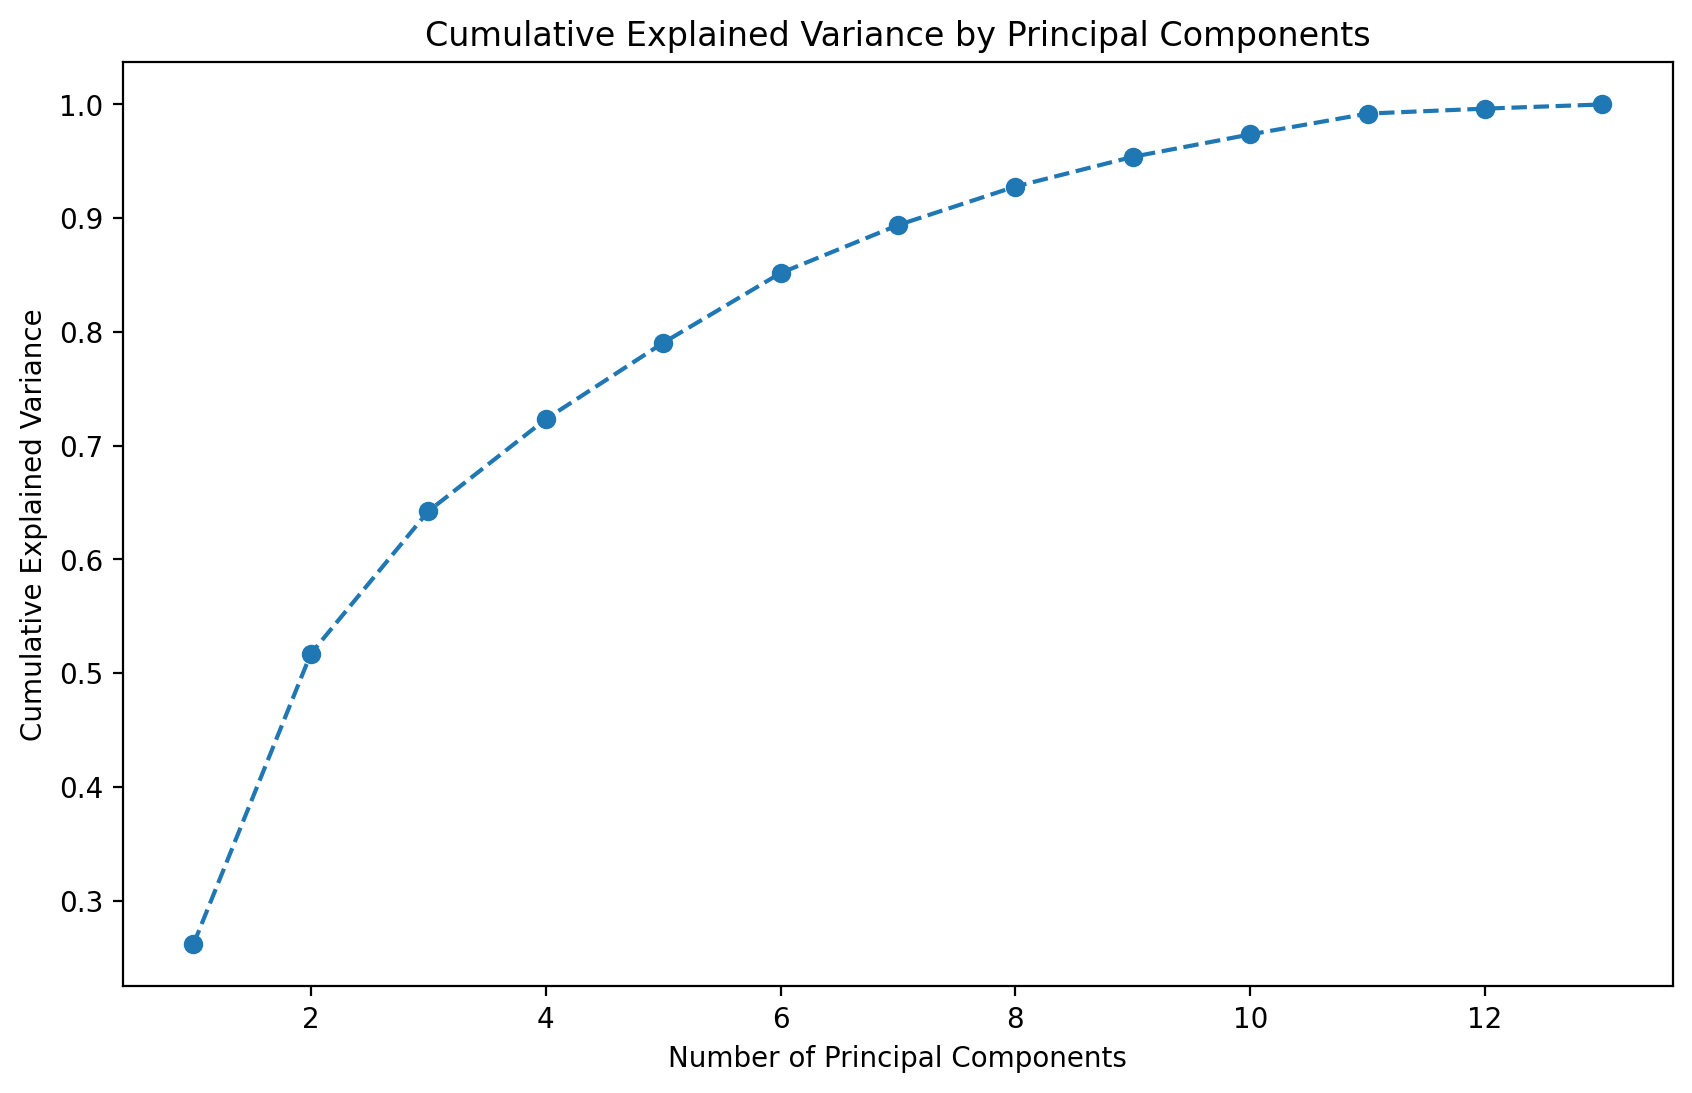

In [ ]:
# Scale the data

# Standardize the data

# numeric columns
numeric_columns = data.select_dtypes(include=['number']).columns

scaler = StandardScaler()
scaled_data = scaler.fit_transform(data[numeric_columns])

# Check for missing values in the scaled data
#print(pd.DataFrame(scaled_data).isnull().sum())

#from sklearn.impute import SimpleImputer

# Impute missing values in numeric data using the mean
#imputer = SimpleImputer(strategy='mean')
#scaled_data_imputed = imputer.fit_transform(scaled_data)

print("Scaled Data:\n", scaled_data)





# Apply PCA

#pca = PCA()
pca = PCA(n_components=data[numeric_columns].shape[1])
pca_data = pca.fit_transform(scaled_data)

print("\nPCA Transformed Data:\n", pca_data)

# Transforming the data into principal components
pca_df = pd.DataFrame(pca_data, columns=[f'PC{i+1}' for i in range(data[numeric_columns].shape[1])])

print("\nPrincipal components\n", pca_df)




# Visualize explained variance for each component

# Display explained variance for each component
explained_variance = pca.explained_variance_ratio_
explained_variance_cumsum = explained_variance.cumsum()

# Visualize the explained variance
plt.figure(figsize=(10,6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance_cumsum, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.savefig('gdrive/MyDrive/WS5/ws5data/group_7_ws5_graph_4.jpg')
plt.show()






# Visualize explained variance for each component

# Explained variance
#explained_variance = pca.explained_variance_ratio_
#cumulative_variance = np.cumsum(explained_variance)

# Plot explained variance
#plt.figure(figsize=(10, 5))
#plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.5, align='center', label='Individual explained variance')
#plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', label='Cumulative explained variance')
#plt.ylabel('Explained variance ratio')
#plt.xlabel('Principal components')
#plt.legend(loc='best')
#plt.title('Explained Variance by Principal Components')
#plt.show()

**Visualizing High-Dimensional Data in 2D Using PCA**
- For visualization purposes, you need to reduce the data to 2 dimensions.
- Visualize the Data in 2D: Plot the first two principal components in a scatter plot. While the scatter plot provides a 2D view of the data, it is important to note that some information (variance) has been lost during dimensionality reduction.
- Examine the explained variance of the first two components to see how much information you retain.





<Figure size 1000x600 with 0 Axes>

Text(0.5, 1.0, '2D Visualization of Data using First Two Principal Components')

Text(0.5, 0, 'Principal Component 1')

Text(0, 0.5, 'Principal Component 2')

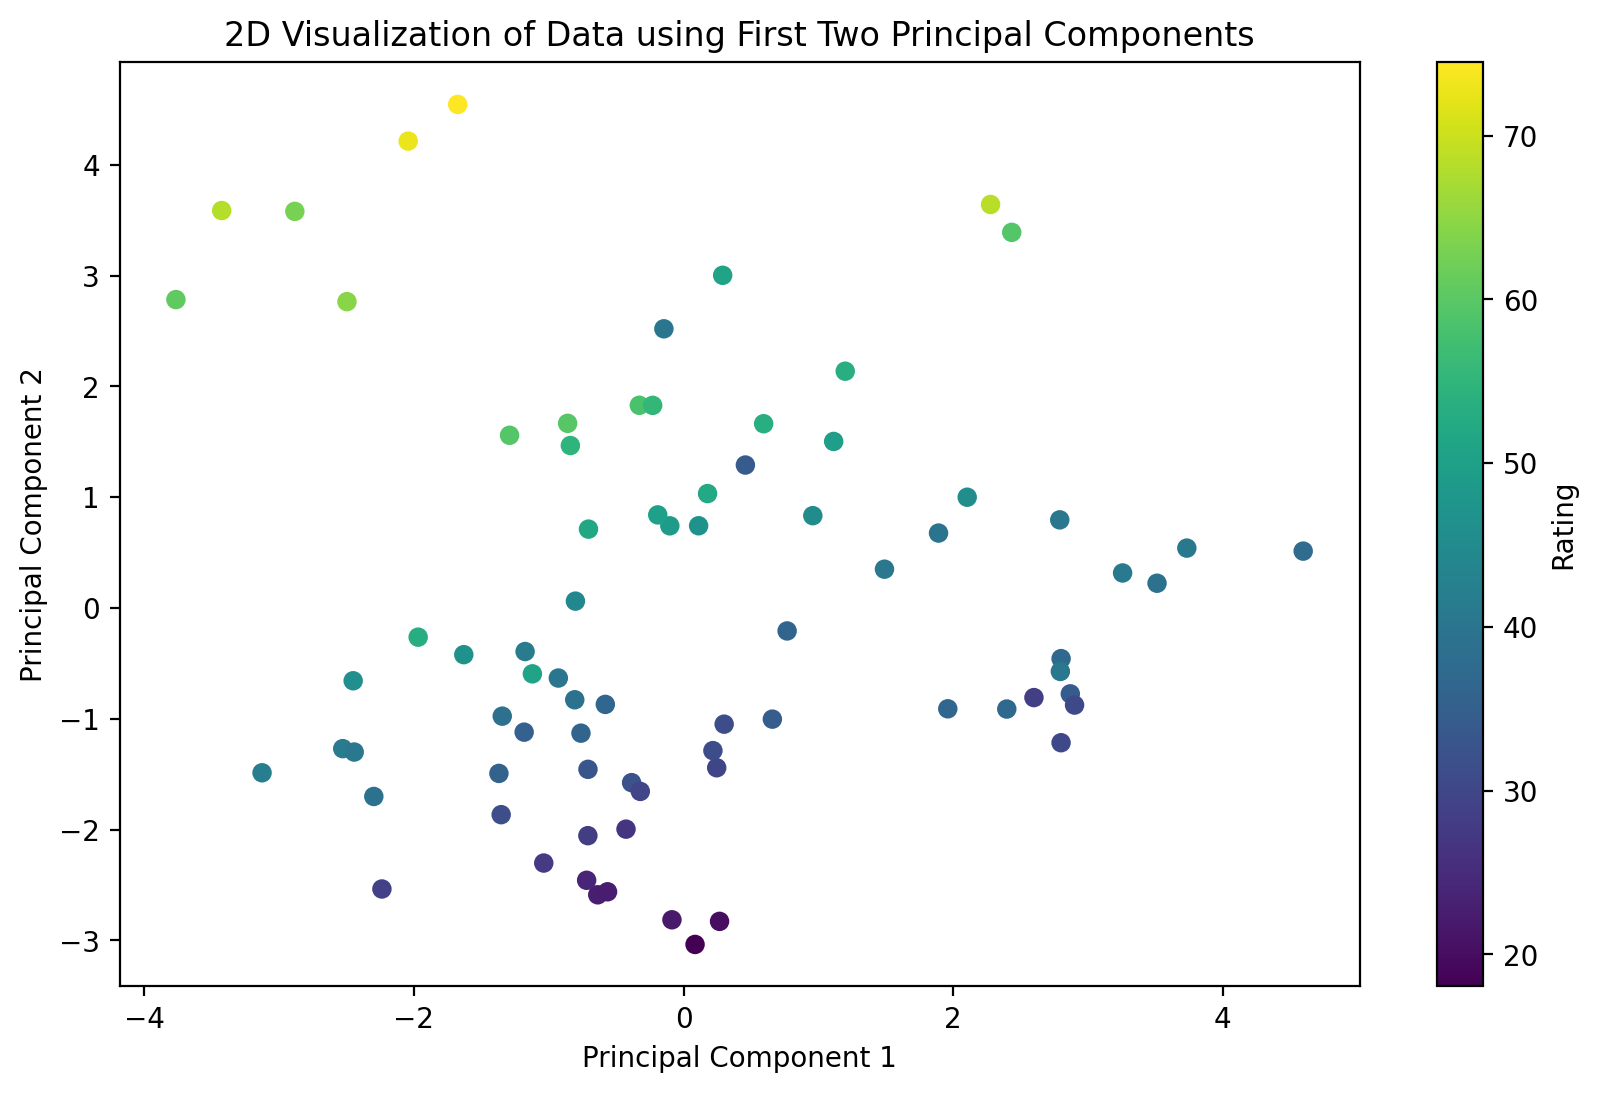

Explained variance by the first two components: [0.26162725 0.25551902]
Cumulative explained variance by the first two components: 0.517146269182874


In [ ]:
# 2D visualization of the first two principal components
plt.figure(figsize=(10,6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=data['Rating'], cmap='viridis')
plt.title('2D Visualization of Data using First Two Principal Components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Rating')
plt.savefig('gdrive/MyDrive/WS5/ws5data/group_7_ws5_graph_5.jpg')
plt.show()

# Standardize the data
#scaler = StandardScaler()
#scaled_data = scaler.fit_transform(df)

# Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
pca_2d = pca.fit_transform(scaled_data)

# Explained variance
explained_variance = pca.explained_variance_ratio_

# Print explained variance
print("Explained variance by the first two components:", explained_variance)
print("Cumulative explained variance by the first two components:", explained_variance.sum())



# Scatter plot of the first two principal components
#plt.figure(figsize=(10, 6))
#plt.scatter(pca_2d[:, 0], pca_2d[:, 1], c='blue', edgecolor='k', s=50)
#plt.xlabel('Principal Component 1')
#plt.ylabel('Principal Component 2')
#plt.title('2D PCA Scatter Plot')
#plt.grid(True)
#plt.show()



**Reflection on Results:**

**Question 1:** Why is it essential to handle missing data before performing analysis, and what methods do you use in this workshop to handle missing values?

**Answer:** Handling missing data is essential because many algorithms, such as PCA, cannot process datasets with missing values. Missing data can distort analyses and lead to incorrect conclusions by introducing biases or inconsistencies. In this workshop, we used imputation to handle missing values. Specifically, we imputed missing numeric values using median. This ensures that the dataset is complete, and no essential information is lost.


**Question 2:** Which variables seem most important in the first two principal components?

**Answer:** To determine the most important variables in the first two principal components, we examine the PCA loadings (the coefficients of the original features in the principal components). Variables with higher absolute values in the first two components contribute more to explaining the variance. Based on typical cereal dataset patterns, features like calories, sugars, and fiber often have significant influence. However, the exact variables can be confirmed by inspecting the PCA loadings matrix after PCA transformation.


**Question 3:** Based on the explained variance plot, how many components would you consider keeping for further analysis?

**Answer:** From the explained variance plot, we can observe the cumulative explained variance by the number of components. Typically, we aim to retain components that explain a significant proportion of the variance, such as 95% or more. If the explained variance plot shows that, say, the first 3 or 4 components capture this much variance, then I would consider keeping 3-4 components for further analysis. The scree plot would help visualize the "elbow point," where adding more components yields diminishing returns in explained variance.


**Question 4:** Did any preprocessing steps (like one-hot encoding) noticeably influence the PCA results?

**Answer:** Yes, one-hot encoding can influence PCA results. One-hot encoding increases the dimensionality of the dataset by converting categorical variables into multiple binary columns, which can change how variance is distributed across the features. In this workshop, encoding the categorical Manufacturer and Type columns using one-hot encoding introduced new variables, possibly affecting how PCA distributes the explained variance across components. Features like manufacturer categories may have had less variance compared to continuous variables like sugars or calories.


**Question 5:** After performing PCA, how would you decide the optimal number of components for future analysis or model building?

**Answer:** The optimal number of components can be decided by:

•	Explained variance: Typically, we aim to retain enough components to explain at least 95% of the total variance. The explained variance plot (cumulative explained variance) can help identify how many components meet this criterion.

•	Scree plot: We would look for the "elbow point" where the explained variance begins to level off. This point usually indicates a good trade-off between retaining variance and reducing dimensionality.

•	Cross-validation in model building: If PCA is used in conjunction with machine learning models, we could validate the performance of different numbers of components using cross-validation to choose the optimal number for the best model performance.


**Question 6:** How might the results from PCA be used in further analyses or model building?

**Answer:** The results from PCA can be used in several ways for further analysis or model building:

•	Dimensionality reduction: PCA reduces the dataset's dimensionality, allowing for faster and more efficient model training, particularly in cases where the original dataset had many correlated features.

•	Feature extraction: The principal components represent new features that capture the most variance in the data. These features can be used as inputs to machine learning algorithms, potentially improving model performance and generalization.

•	Visualization: PCA allows us to visualize high-dimensional data in 2D or 3D, making it easier to identify patterns, clusters, or outliers in the data.

•	Multicollinearity reduction: By transforming correlated features into uncorrelated principal components, PCA helps mitigate issues with multicollinearity in models like linear regression. This leads to more stable model estimates and better interpretability.
